In [2]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Setup working successfully!")

Pandas version: 3.0.6
NumPy version: 2.4.6
Setup working successfully!


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/hillstrom.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [4]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 64000
Number of columns: 12

Column names:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']


In [5]:
print("DATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

DATA TYPES
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
segment                str
visit                int64
conversion           int64
spend              float64
dtype: object

MISSING VALUES
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6562


In [7]:
duplicates = df[df.duplicated(keep=False)]

print("Duplicate records:", len(duplicates))
duplicates.head(10)

Duplicate records: 7634


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
16,5,1) $0 - $100,29.99,1,0,Surburban,0,Phone,Mens E-Mail,0,0,0.0
20,9,1) $0 - $100,29.99,0,1,Surburban,1,Phone,No E-Mail,0,0,0.0
23,2,1) $0 - $100,29.99,0,1,Urban,1,Phone,No E-Mail,0,0,0.0
33,9,1) $0 - $100,29.99,1,0,Surburban,1,Phone,Mens E-Mail,0,0,0.0
34,3,1) $0 - $100,29.99,1,0,Rural,0,Web,Womens E-Mail,0,0,0.0
45,10,1) $0 - $100,29.99,1,0,Surburban,0,Phone,No E-Mail,0,0,0.0
52,7,1) $0 - $100,29.99,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
79,2,1) $0 - $100,29.99,0,1,Surburban,0,Phone,Mens E-Mail,0,0,0.0
107,12,1) $0 - $100,29.99,0,1,Urban,1,Web,No E-Mail,0,0,0.0
114,4,1) $0 - $100,29.99,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


In [8]:
print(df.index.is_unique)
print(df.index[:10].tolist())

True
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [9]:
for col in ["segment", "channel", "zip_code", "history_segment"]:
    print(f"\n{col}:")
    print(df[col].value_counts())
    


segment:
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

channel:
channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64

zip_code:
zip_code
Surburban    28776
Urban        25661
Rural         9563
Name: count, dtype: int64

history_segment:
history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308
Name: count, dtype: int64


In [10]:
df.describe()

,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [11]:
conversion_by_segment = df.groupby("segment")["conversion"].mean() * 100

print("Conversion Rate by Experiment Group:")
print(conversion_by_segment.round(2))

Conversion Rate by Experiment Group:
segment
Mens E-Mail      1.25
No E-Mail        0.57
Womens E-Mail    0.88
Name: conversion, dtype: float64


In [12]:
mens_rate = df.loc[df["segment"] == "Mens E-Mail", "conversion"].mean()
control_rate = df.loc[df["segment"] == "No E-Mail", "conversion"].mean()

uplift_mens = mens_rate - control_rate

print(f"Mens E-Mail conversion: {mens_rate:.4%}")
print(f"Control conversion: {control_rate:.4%}")
print(f"Observed uplift: {uplift_mens:.4%}")

Mens E-Mail conversion: 1.2531%
Control conversion: 0.5726%
Observed uplift: 0.6805%


In [14]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["segment"], df["conversion"])

print(table)

chi2, p_value, dof, expected = chi2_contingency(table)

print("\nChi-square statistic:", chi2)
print("p-value:", p_value)

conversion         0    1
segment                  
Mens E-Mail    21040  267
No E-Mail      21184  122
Womens E-Mail  21198  189

Chi-square statistic: 55.258039933229625
p-value: 1.0020031529493264e-12


In [15]:
from scipy.stats import chi2_contingency

ab_data = df[df["segment"].isin(["Mens E-Mail", "No E-Mail"])]

ab_table = pd.crosstab(ab_data["segment"], ab_data["conversion"])

print(ab_table)

chi2, p_value, dof, expected = chi2_contingency(ab_table)

mens_rate = ab_data.loc[
    ab_data["segment"] == "Mens E-Mail", "conversion"
].mean()

control_rate = ab_data.loc[
    ab_data["segment"] == "No E-Mail", "conversion"
].mean()

absolute_uplift = mens_rate - control_rate
relative_lift = (mens_rate - control_rate) / control_rate

print(f"\nMens Email Conversion Rate: {mens_rate:.4%}")
print(f"Control Conversion Rate: {control_rate:.4%}")
print(f"Absolute Uplift: {absolute_uplift:.4%}")
print(f"Relative Lift: {relative_lift:.2%}")
print(f"p-value: {p_value:.6g}")

conversion       0    1
segment                
Mens E-Mail  21040  267
No E-Mail    21184  122

Mens Email Conversion Rate: 1.2531%
Control Conversion Rate: 0.5726%
Absolute Uplift: 0.6805%
Relative Lift: 118.84%
p-value: 2.23084e-13


In [16]:
from statsmodels.stats.proportion import confint_proportions_2indep

mens_success = ab_data.loc[
    ab_data["segment"] == "Mens E-Mail", "conversion"
].sum()

mens_total = (ab_data["segment"] == "Mens E-Mail").sum()

control_success = ab_data.loc[
    ab_data["segment"] == "No E-Mail", "conversion"
].sum()

control_total = (ab_data["segment"] == "No E-Mail").sum()

ci_low, ci_high = confint_proportions_2indep(
    mens_success,
    mens_total,
    control_success,
    control_total,
    method="wald"
)

print(f"95% CI for uplift: {ci_low:.4%} to {ci_high:.4%}")

ModuleNotFoundError: No module named 'statsmodels'

In [17]:
from statsmodels.stats.proportion import confint_proportions_2indep

mens_success = ab_data.loc[
    ab_data["segment"] == "Mens E-Mail", "conversion"
].sum()

mens_total = (ab_data["segment"] == "Mens E-Mail").sum()

control_success = ab_data.loc[
    ab_data["segment"] == "No E-Mail", "conversion"
].sum()

control_total = (ab_data["segment"] == "No E-Mail").sum()

ci_low, ci_high = confint_proportions_2indep(
    mens_success,
    mens_total,
    control_success,
    control_total,
    method="wald"
)

print(f"95% CI for uplift: {ci_low:.4%} to {ci_high:.4%}")

95% CI for uplift: 0.5000% to 0.8610%


In [18]:
df["treatment"] = (df["segment"] != "No E-Mail").astype(int)

print(df[["segment", "treatment"]].drop_duplicates().sort_values("segment"))

         segment  treatment
3    Mens E-Mail          1
1      No E-Mail          0
0  Womens E-Mail          1


In [19]:
print("Treatment distribution:")
print(df["treatment"].value_counts())

print("\nConversion by treatment:")
print(df.groupby("treatment")["conversion"].mean() * 100)

Treatment distribution:
treatment
1    42694
0    21306
Name: count, dtype: int64

Conversion by treatment:
treatment
0    0.572609
1    1.068066
Name: conversion, dtype: float64


In [20]:
conversion_by_segment = (
    df.groupby("segment")["conversion"]
    .mean()
    .mul(100)
    .round(4)
)

print("Conversion Rate by Segment:")
print(conversion_by_segment)

Conversion Rate by Segment:
segment
Mens E-Mail      1.2531
No E-Mail        0.5726
Womens E-Mail    0.8837
Name: conversion, dtype: float64


In [21]:
print("Treatment values:")
print(df["treatment"].unique())

print("\nOutcome values:")
print(df["conversion"].unique())

print("\nTreatment × Conversion:")
print(pd.crosstab(df["treatment"], df["conversion"]))

Treatment values:
[1 0]

Outcome values:
[0 1]

Treatment × Conversion:
conversion      0    1
treatment             
0           21184  122
1           42238  456


In [22]:
features = [
    "recency",
    "history_segment",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel"
]

X = df[features]
treatment = df["treatment"]
y = df["conversion"]

print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("Treatment shape:", treatment.shape)
print("Outcome shape:", y.shape)

Features:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']

X shape: (64000, 8)
Treatment shape: (64000,)
Outcome shape: (64000,)


In [23]:
print("Categorical columns:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nNumerical columns:")
print(X.select_dtypes(exclude="object").columns.tolist())

Categorical columns:
['history_segment', 'zip_code', 'channel']

Numerical columns:
['recency', 'history', 'mens', 'womens', 'newbie']


C:\Users\Hp\AppData\Local\Temp\ipykernel_25836\861607206.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include="object").columns.tolist())


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["history_segment", "zip_code", "channel"]
numerical_features = ["recency", "history", "mens", "womens", "newbie"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

X_encoded = preprocessor.fit_transform(X)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (64000, 8)
Encoded X shape: (64000, 18)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, treatment_train, treatment_test, y_train, y_test = train_test_split(
    X_encoded,
    treatment,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining features:", X_train.shape[1])
print("Testing features:", X_test.shape[1])

print("\nTraining treatment distribution:")
print(treatment_train.value_counts())

print("\nTesting treatment distribution:")
print(treatment_test.value_counts())

Training samples: 51200
Testing samples: 12800

Training features: 18
Testing features: 18

Training treatment distribution:
treatment
1    34113
0    17087
Name: count, dtype: int64

Testing treatment distribution:
treatment
1    8581
0    4219
Name: count, dtype: int64


In [26]:
from sklearn.ensemble import RandomForestClassifier

# Treatment group
treatment_mask = treatment_train == 1

model_treatment = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model_treatment.fit(
    X_train[treatment_mask],
    y_train[treatment_mask]
)

# Control group
control_mask = treatment_train == 0

model_control = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model_control.fit(
    X_train[control_mask],
    y_train[control_mask]
)

print("Treatment model trained successfully!")
print("Control model trained successfully!")

Treatment model trained successfully!
Control model trained successfully!


In [27]:
# Predict conversion probability under treatment
p_treatment = model_treatment.predict_proba(X_test)[:, 1]

# Predict conversion probability under control
p_control = model_control.predict_proba(X_test)[:, 1]

# Individual uplift score
uplift_score = p_treatment - p_control

print("First 10 Treatment probabilities:")
print(p_treatment[:10])

print("\nFirst 10 Control probabilities:")
print(p_control[:10])

print("\nFirst 10 Uplift scores:")
print(uplift_score[:10])

First 10 Treatment probabilities:
[0.02  0.295 0.    0.    0.    0.    0.17  0.    0.07  0.   ]

First 10 Control probabilities:
[0.085      0.         0.95668039 0.005      0.         0.90222083
 0.         0.         0.         0.        ]

First 10 Uplift scores:
[-0.065       0.295      -0.95668039 -0.005       0.         -0.90222083
  0.17        0.          0.07        0.        ]


In [28]:
uplift_results = df.loc[X_test.index, [
    "id",
    "segment",
    "treatment",
    "conversion"
]].copy()

uplift_results["predicted_treatment_probability"] = p_treatment
uplift_results["predicted_control_probability"] = p_control
uplift_results["uplift_score"] = uplift_score

print(uplift_results.head(10))

AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [29]:
# Get the original test-row indices
_, test_indices = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Test indices:", len(test_indices))

Test indices: 12800


In [30]:
uplift_results = df.loc[test_indices, [
    "id",
    "segment",
    "treatment",
    "conversion"
]].copy()

uplift_results["predicted_treatment_probability"] = p_treatment
uplift_results["predicted_control_probability"] = p_control
uplift_results["uplift_score"] = uplift_score

print("Uplift results shape:", uplift_results.shape)
print()
print(uplift_results.head(10))

KeyError: "['id'] not in index"

In [31]:

uplift_results = df.loc[test_indices, [
    "segment",
    "treatment",
    "conversion"
]].copy()

uplift_results["predicted_treatment_probability"] = p_treatment
uplift_results["predicted_control_probability"] = p_control
uplift_results["uplift_score"] = uplift_score

print("Uplift results shape:", uplift_results.shape)
print()
print(uplift_results.head(10))


Uplift results shape: (12800, 6)

             segment  treatment  conversion  predicted_treatment_probability  \
21990    Mens E-Mail          1           0                            0.020   
34555    Mens E-Mail          1           0                            0.295   
43005      No E-Mail          0           0                            0.000   
60281    Mens E-Mail          1           0                            0.000   
7561       No E-Mail          0           0                            0.000   
55698      No E-Mail          0           0                            0.000   
2951   Womens E-Mail          1           0                            0.170   
26754  Womens E-Mail          1           0                            0.000   
40229  Womens E-Mail          1           0                            0.070   
26624      No E-Mail          0           0                            0.000   

       predicted_control_probability  uplift_score  
21990                       0.08

In [32]:
print("Uplift Score Summary:")
print(uplift_results["uplift_score"].describe())

print("\nPositive uplift customers:",
      (uplift_results["uplift_score"] > 0).sum())

print("Zero uplift customers:",
      (uplift_results["uplift_score"] == 0).sum())

print("Negative uplift customers:",
      (uplift_results["uplift_score"] < 0).sum())

Uplift Score Summary:
count    12800.000000
mean         0.014951
std          0.156643
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.005000
max          1.000000
Name: uplift_score, dtype: float64

Positive uplift customers: 4079
Zero uplift customers: 6161
Negative uplift customers: 2560


In [33]:
top_uplift = uplift_results.sort_values(
    "uplift_score",
    ascending=False
).head(20)

print(top_uplift.to_string(index=False))

      segment  treatment  conversion  predicted_treatment_probability  predicted_control_probability  uplift_score
  Mens E-Mail          1           0                         1.000000                          0.000      1.000000
    No E-Mail          0           0                         1.000000                          0.000      1.000000
Womens E-Mail          1           0                         1.000000                          0.000      1.000000
  Mens E-Mail          1           0                         0.985000                          0.005      0.980000
    No E-Mail          0           0                         0.970558                          0.000      0.970558
Womens E-Mail          1           0                         0.970558                          0.000      0.970558
Womens E-Mail          1           0                         0.970000                          0.000      0.970000
    No E-Mail          0           0                         0.970000           

In [34]:
uplift_results["uplift_decile"] = pd.qcut(
    uplift_results["uplift_score"],
    q=10,
    duplicates="drop"
)

decile_summary = uplift_results.groupby(
    "uplift_decile",
    observed=True
).agg(
    customers=("conversion", "count"),
    conversions=("conversion", "sum"),
    conversion_rate=("conversion", "mean")
)

decile_summary["conversion_rate"] = (
    decile_summary["conversion_rate"] * 100
).round(4)

print(decile_summary)

                     customers  conversions  conversion_rate
uplift_decile                                               
(-1.001, -0.015]          1369           16           1.1687
(-0.015, -0.000883]       1191           14           1.1755
(-0.000883, 0.0]          6161           52           0.8440
(0.0, 0.005]              1038           10           0.9634
(0.005, 0.01]              574            4           0.6969
(0.01, 0.045]             1188            9           0.7576
(0.045, 1.0]              1279           11           0.8600


In [35]:
decile_uplift = uplift_results.groupby(
    ["uplift_decile", "treatment"],
    observed=True
)["conversion"].mean().unstack()

decile_uplift.columns = ["Control", "Treatment"]

decile_uplift["Observed_Uplift"] = (
    decile_uplift["Treatment"] - decile_uplift["Control"]
)

decile_uplift = decile_uplift * 100

print(decile_uplift.round(4))

                     Control  Treatment  Observed_Uplift
uplift_decile                                           
(-1.001, -0.015]      0.2203     1.6393           1.4191
(-0.015, -0.000883]   0.5089     1.5038           0.9949
(-0.000883, 0.0]      0.4420     1.0424           0.6004
(0.0, 0.005]          0.8955     0.9957           0.1002
(0.005, 0.01]         0.5495     0.7653           0.2159
(0.01, 0.045]         0.9732     0.6435          -0.3297
(0.045, 1.0]          0.4902     1.0333           0.5431


In [36]:
from sklift.metrics import qini_auc_score, uplift_auc_score

qini_score = qini_auc_score(
    y_true=y_test,
    uplift=uplift_score,
    treatment=treatment_test
)

auuc_score = uplift_auc_score(
    y_true=y_test,
    uplift=uplift_score,
    treatment=treatment_test
)

print("Qini AUC:", qini_score)
print("AUUC:", auuc_score)

Qini AUC: -0.12237435543897983
AUUC: -0.005860523980475619


C:\Users\Hp\OneDrive\Desktop\Experimentation-Uplift-Modeling\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\Hp\OneDrive\Desktop\Experimentation-Uplift-Modeling\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


In [37]:
from sklearn.linear_model import LogisticRegression

# Treatment model
model_treatment_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_treatment_lr.fit(
    X_train[treatment_mask],
    y_train[treatment_mask]
)

# Control model
model_control_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_control_lr.fit(
    X_train[control_mask],
    y_train[control_mask]
)

# Predict probabilities
p_treatment_lr = model_treatment_lr.predict_proba(
    X_test
)[:, 1]

p_control_lr = model_control_lr.predict_proba(
    X_test
)[:, 1]

# Predicted uplift
uplift_score_lr = p_treatment_lr - p_control_lr

print("First 10 Treatment probabilities:")
print(p_treatment_lr[:10])

print("\nFirst 10 Control probabilities:")
print(p_control_lr[:10])

print("\nFirst 10 Uplift scores:")
print(uplift_score_lr[:10])

First 10 Treatment probabilities:
[0.0126836  0.00859515 0.00957406 0.01415543 0.00693932 0.00883787
 0.02409781 0.00649156 0.00703215 0.00841634]

First 10 Control probabilities:
[0.00659547 0.00528592 0.00350278 0.01732424 0.0018248  0.00469675
 0.0095497  0.00363517 0.00258039 0.00420824]

First 10 Uplift scores:
[ 0.00608813  0.00330923  0.00607129 -0.00316882  0.00511452  0.00414112
  0.01454811  0.00285638  0.00445176  0.0042081 ]


In [38]:
qini_lr = qini_auc_score(
    y_true=y_test,
    uplift=uplift_score_lr,
    treatment=treatment_test
)

auuc_lr = uplift_auc_score(
    y_true=y_test,
    uplift=uplift_score_lr,
    treatment=treatment_test
)

print("Logistic Regression Qini AUC:", qini_lr)
print("Logistic Regression AUUC:", auuc_lr)

Logistic Regression Qini AUC: -0.0007671097445147044
Logistic Regression AUUC: -7.990196245975551e-05


C:\Users\Hp\OneDrive\Desktop\Experimentation-Uplift-Modeling\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\Hp\OneDrive\Desktop\Experimentation-Uplift-Modeling\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


In [39]:
from sklearn.ensemble import RandomForestClassifier

# Create transformed target
y_transformed = np.where(
    treatment_train == 1,
    y_train,
    -y_train
)

class_transformation_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

class_transformation_model.fit(
    X_train,
    y_transformed
)

# Predict probability
p_transformed = class_transformation_model.predict_proba(X_test)[:, 1]

# Convert to uplift score
uplift_score_ct = 2 * p_transformed - 1

print("First 10 Class Transformation uplift scores:")
print(uplift_score_ct[:10])

First 10 Class Transformation uplift scores:
[0.99       0.97       0.90885038 1.         1.         0.96499266
 0.99       1.         1.         1.        ]


In [40]:
from sklearn.ensemble import RandomForestRegressor

# Treatment probability in the training data
propensity = treatment_train.mean()

print("Treatment propensity:", propensity)

# Class Transformation target
y_transformed_ct = (
    y_train * (treatment_train - propensity)
    / (propensity * (1 - propensity))
)

# Train regression model
class_transformation_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=50
)

class_transformation_model.fit(
    X_train,
    y_transformed_ct
)

# Predicted individual uplift
uplift_score_ct = class_transformation_model.predict(X_test)

print("\nFirst 10 Class Transformation uplift scores:")
print(uplift_score_ct[:10])

Treatment propensity: 0.66626953125

First 10 Class Transformation uplift scores:
[-0.00135561  0.02129385 -0.02562256 -0.00489656  0.00687629 -0.02894402
  0.02966614  0.00713602  0.01182924 -0.00120987]


In [41]:
qini_ct = qini_auc_score(
    y_true=y_test,
    uplift=uplift_score_ct,
    treatment=treatment_test
)

auuc_ct = uplift_auc_score(
    y_true=y_test,
    uplift=uplift_score_ct,
    treatment=treatment_test
)

print("Class Transformation Qini AUC:", qini_ct)
print("Class Transformation AUUC:", auuc_ct)


Class Transformation Qini AUC: -0.0982378954236482
Class Transformation AUUC: -0.004700411580720395


C:\Users\Hp\OneDrive\Desktop\Experimentation-Uplift-Modeling\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\Hp\OneDrive\Desktop\Experimentation-Uplift-Modeling\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


In [42]:
print(
    df.groupby("segment")["conversion"]
      .agg(["count", "sum", "mean"])
      .assign(conversion_rate=lambda x: x["mean"] * 100)
      .round(4)
)

               count  sum    mean  conversion_rate
segment                                           
Mens E-Mail    21307  267  0.0125           1.2531
No E-Mail      21306  122  0.0057           0.5726
Womens E-Mail  21387  189  0.0088           0.8837


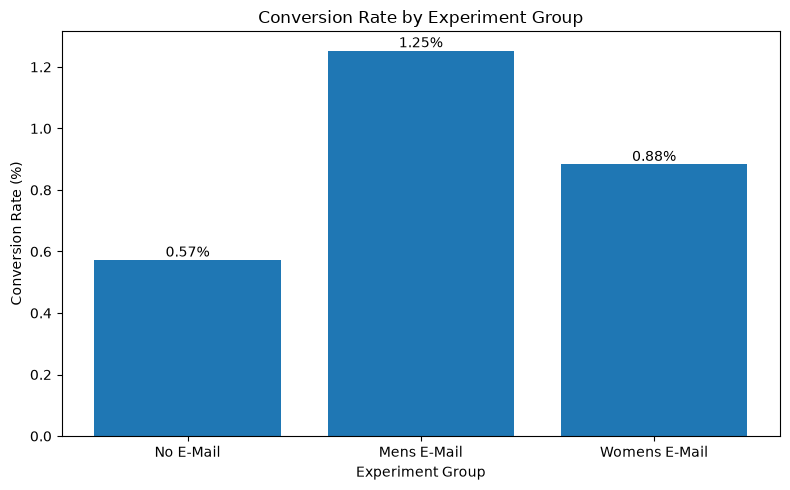

In [43]:
import matplotlib.pyplot as plt

conversion_rates = (
    df.groupby("segment")["conversion"]
      .mean()
      .mul(100)
      .reindex(["No E-Mail", "Mens E-Mail", "Womens E-Mail"])
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    conversion_rates.index,
    conversion_rates.values
)

plt.title("Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

for bar, value in zip(bars, conversion_rates.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../results/figures/experiment_conversion_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
from sklift.viz import plot_qini_curve

plt.figure(figsize=(8, 6))

plot_qini_curve(
    y_true=y_test,
    uplift=uplift_score_lr,
    treatment=treatment_test
)

plt.title("Qini Curve - Logistic Regression Two-Model")
plt.tight_layout()

plt.savefig(
    "../results/figures/qini_curve_logistic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ImportError: cannot import name 'check_matplotlib_support' from 'sklearn.utils' (C:\Users\Hp\OneDrive\Desktop\Experimentation-Uplift-Modeling\.venv\Lib\site-packages\sklearn\utils\__init__.py)

C:\Users\Hp\OneDrive\Desktop\Experimentation-Uplift-Modeling\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


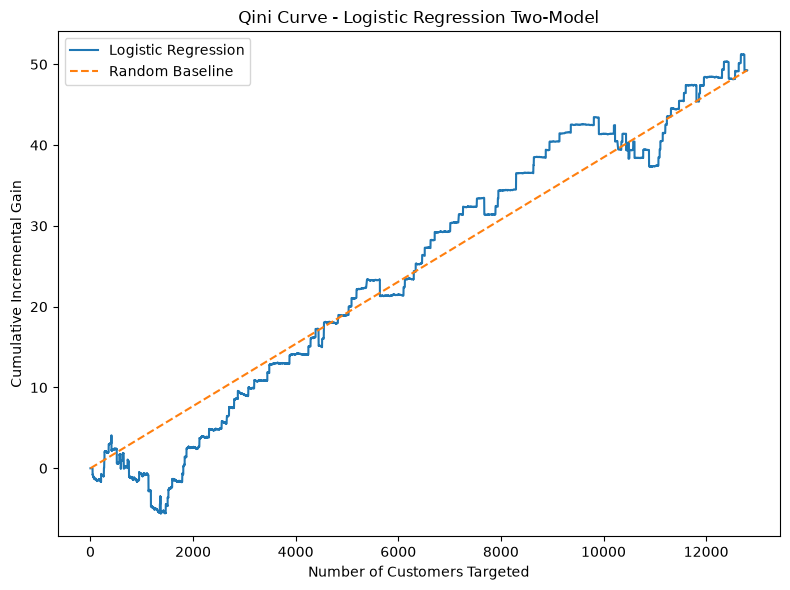

In [45]:
from sklift.metrics import qini_curve
import matplotlib.pyplot as plt
import numpy as np

# Calculate Qini curve
x, y = qini_curve(
    y_true=y_test,
    uplift=uplift_score_lr,
    treatment=treatment_test
)

# Perfect/random baseline
x_random = np.array([0, x.max()])
y_random = np.array([0, y[-1]])

plt.figure(figsize=(8, 6))

plt.plot(x, y, label="Logistic Regression")
plt.plot(x_random, y_random, linestyle="--", label="Random Baseline")

plt.title("Qini Curve - Logistic Regression Two-Model")
plt.xlabel("Number of Customers Targeted")
plt.ylabel("Cumulative Incremental Gain")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/qini_curve_logistic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
# Create a copy of test results
final_results = df.loc[test_indices, [
    "segment",
    "treatment",
    "conversion"
]].copy()

# Add predicted probabilities and uplift
final_results["treatment_probability"] = p_treatment_lr
final_results["control_probability"] = p_control_lr
final_results["uplift_score"] = uplift_score_lr

# Create customer segments
final_results["uplift_segment"] = pd.cut(
    final_results["uplift_score"],
    bins=[-np.inf, 0, 0.005, 0.01, np.inf],
    labels=[
        "Negative Uplift",
        "Low Uplift",
        "Moderate Uplift",
        "High Uplift"
    ]
)

# Summary
segment_summary = (
    final_results
    .groupby("uplift_segment", observed=True)
    .agg(
        customers=("uplift_score", "count"),
        average_uplift=("uplift_score", "mean"),
        actual_conversion=("conversion", "mean")
    )
)

segment_summary["average_uplift"] *= 100
segment_summary["actual_conversion"] *= 100

print(segment_summary.round(3))

                 customers  average_uplift  actual_conversion
uplift_segment                                               
Negative Uplift        780          -0.191              0.897
Low Uplift            7875           0.327              0.851
Moderate Uplift       3092           0.645              0.809
High Uplift           1053           1.485              1.614


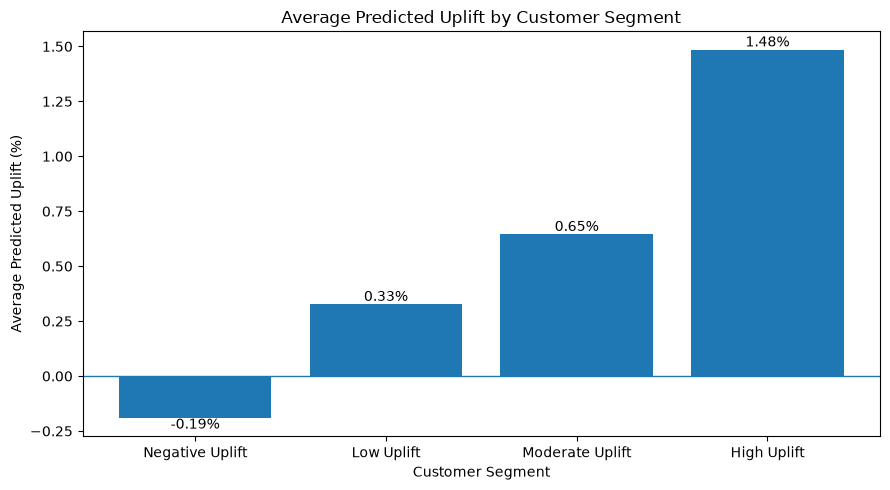

In [47]:
plt.figure(figsize=(9, 5))

segment_order = [
    "Negative Uplift",
    "Low Uplift",
    "Moderate Uplift",
    "High Uplift"
]

plot_data = segment_summary.reindex(segment_order)

bars = plt.bar(
    plot_data.index,
    plot_data["average_uplift"]
)

plt.axhline(0, linewidth=1)

plt.title("Average Predicted Uplift by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Predicted Uplift (%)")

for bar, value in zip(bars, plot_data["average_uplift"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()

plt.savefig(
    "../results/figures/uplift_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# Save final customer-level uplift results

final_results.to_csv(
    "../data/processed/customer_uplift_results.csv",
    index=False
)

print("Final results saved successfully!")
print("Rows:", len(final_results))
print("Columns:", list(final_results.columns))

Final results saved successfully!
Rows: 12800
Columns: ['segment', 'treatment', 'conversion', 'treatment_probability', 'control_probability', 'uplift_score', 'uplift_segment']
